In [3]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the dataset
df = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\Elevate Labs\Task 5\train.csv')

# 3. Requirement A: Statistical Checks
print("--- DATASET STRUCTURE ---")
df.info()

print("\n--- SUMMARY STATISTICS ---")
display(df.describe())

print("\n--- SURVIVAL COUNTS (0 = Died, 1 = Survived) ---")
display(df['Survived'].value_counts())

print("\n--- PASSENGER CLASS COUNTS ---")
display(df['Pclass'].value_counts())

--- DATASET STRUCTURE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- SUMMARY STATISTICS ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- SURVIVAL COUNTS (0 = Died, 1 = Survived) ---


Survived
0    549
1    342
Name: count, dtype: int64


--- PASSENGER CLASS COUNTS ---


Pclass
3    491
1    216
2    184
Name: count, dtype: int64

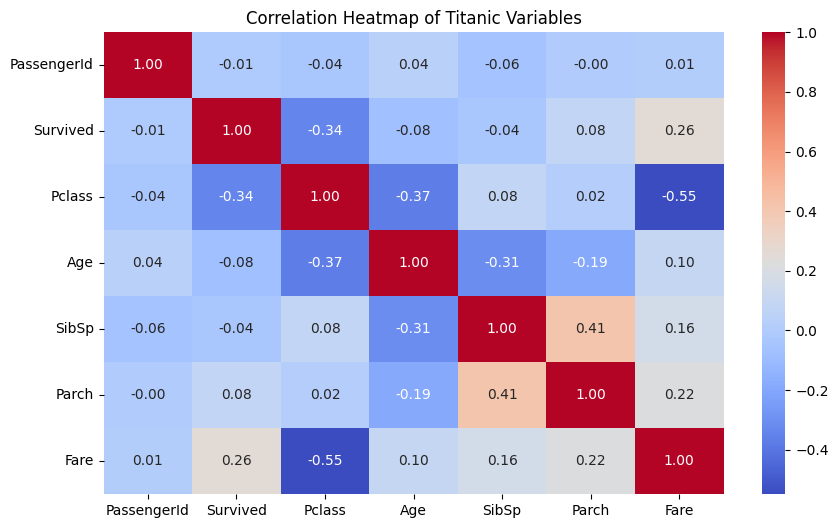

In [4]:
# Cell 2: Correlation Heatmap
plt.figure(figsize=(10, 6))

# Calculate correlation on numeric columns only
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap of Titanic Variables')
plt.show()

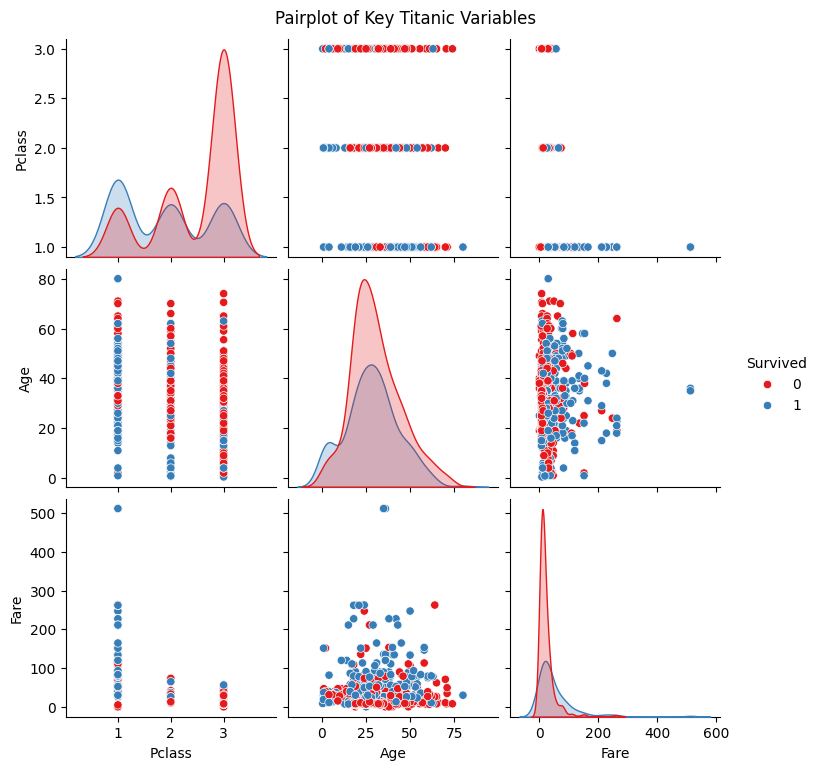

In [5]:
# Cell 3: Pairplot focusing on Survival status
# We use dropna() here so missing ages don't break the chart
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare']].dropna(), hue='Survived', palette='Set1')
plt.suptitle('Pairplot of Key Titanic Variables', y=1.02)
plt.show()

C:\Users\ajasl\AppData\Local\Temp\ipykernel_12536\4126646197.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df, ax=axes[1], palette='Pastel1')


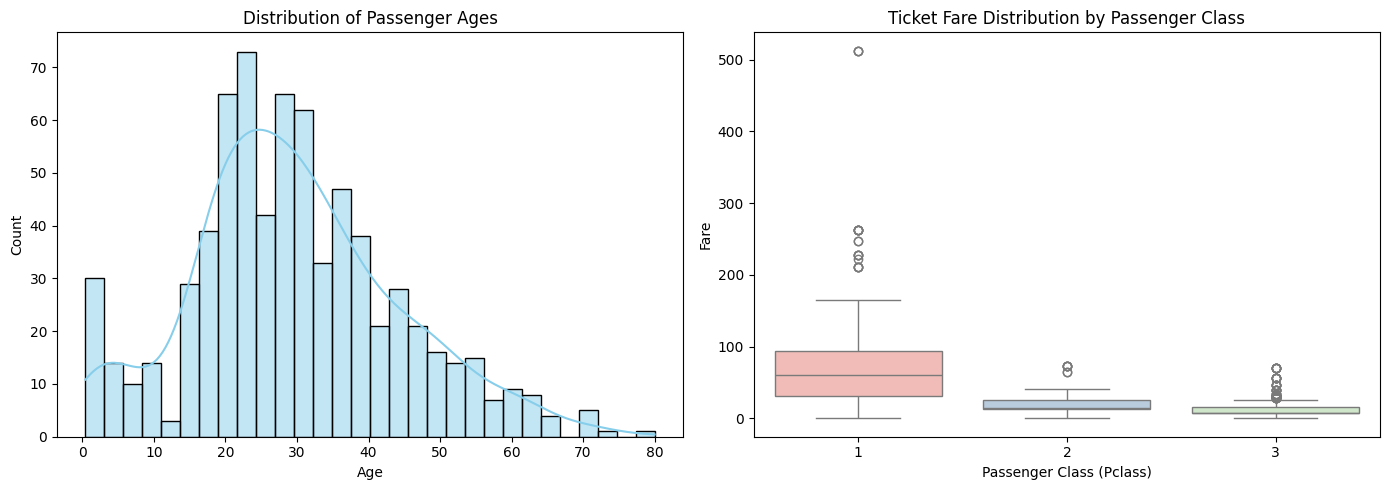

In [6]:
# Cell 4: Distribution of Age (Histogram) and Fare by Class (Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram for Age Distribution
sns.histplot(df['Age'].dropna(), bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Passenger Ages')
axes[0].set_xlabel('Age')

# 2. Boxplot for Fares across Passenger Classes
sns.boxplot(x='Pclass', y='Fare', data=df, ax=axes[1], palette='Pastel1')
axes[1].set_title('Ticket Fare Distribution by Passenger Class')
axes[1].set_xlabel('Passenger Class (Pclass)')
axes[1].set_ylabel('Fare')

plt.tight_layout()
plt.show()

C:\Users\ajasl\AppData\Local\Temp\ipykernel_12536\3445911487.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], errorbar=None, palette='muted')
C:\Users\ajasl\AppData\Local\Temp\ipykernel_12536\3445911487.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], errorbar=None, palette='muted')


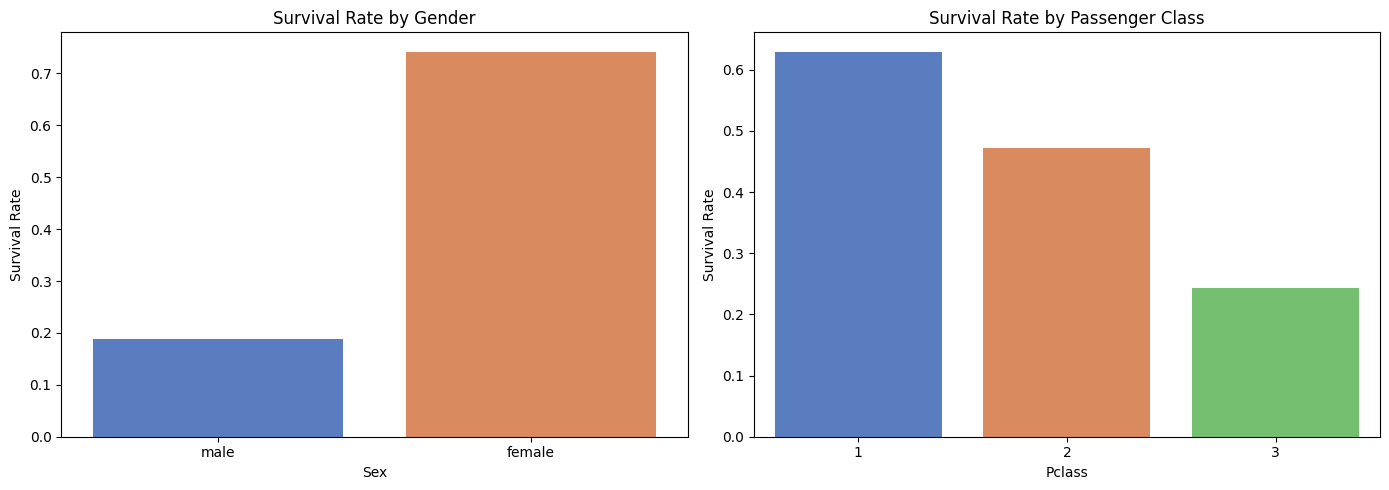

In [7]:
# Cell 5: Survival Rate by Gender and Class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival rate by Gender
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], errorbar=None, palette='muted')
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Survival Rate')

# Survival rate by Passenger Class
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], errorbar=None, palette='muted')
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()